In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/drive/MyDrive/AML_Lab/multiclass_classification_dataset_500_samples.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

First 5 rows:
   Study_Hours  Attendance_Percentage  Assignment_Score  Internal_Marks  \
0        22.48                  84.26             86.79           76.68   
1        19.31                  94.09             81.10           56.73   
2        23.24                  61.01             70.72           52.73   
3        27.62                  80.63             62.24           64.95   
4        18.83                  68.49             78.38           62.45   

  Participation Internet_Access Previous_Grade  Performance_Level  
0        Medium             Yes              B                  1  
1           Low             Yes              B                  1  
2        Medium             Yes              A                  0  
3           Low             Yes              C                  0  
4          High             Yes              B                  0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Col

In [3]:
data["Performance_Level"] = pd.cut(
    data["Internal_Marks"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"]
)

In [4]:
label_encoder = LabelEncoder()
data["Performance_Level"] = label_encoder.fit_transform(data["Performance_Level"])

In [5]:
X = data.drop(["Performance_Level"], axis=1)
y = data["Performance_Level"]

In [6]:
X = pd.get_dummies(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(
        multi_class="multinomial",
        max_iter=1000
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss"
    )
}

In [16]:
results = []

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)

    # Predicting
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_micro = f1_score(y_test, y_pred, average="micro")

    # Store results in a list
    results.append([
        name, acc, prec, rec, f1_weighted, f1_macro, f1_micro
    ])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Model Performance Comparison ---
            Model Name  Accuracy  Precision    Recall  F1 (Weighted)  \
0        Decision Tree  1.000000   1.000000  1.000000       1.000000   
4              XGBoost  1.000000   1.000000  1.000000       1.000000   
1        Random Forest  0.986667   0.986973  0.986667       0.986454   
2  Logistic Regression  0.960000   0.962637  0.960000       0.959303   
3                  KNN  0.653333   0.669445  0.653333       0.609678   

   F1 (Macro)  F1 (Micro)  
0    1.000000    1.000000  
4    1.000000    1.000000  
1    0.981631    0.986667  
2    0.950000    0.960000  
3    0.510885    0.653333  


/tmp/ipykernel_6316/3607437365.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model Name", data=results_df, palette="viridis")


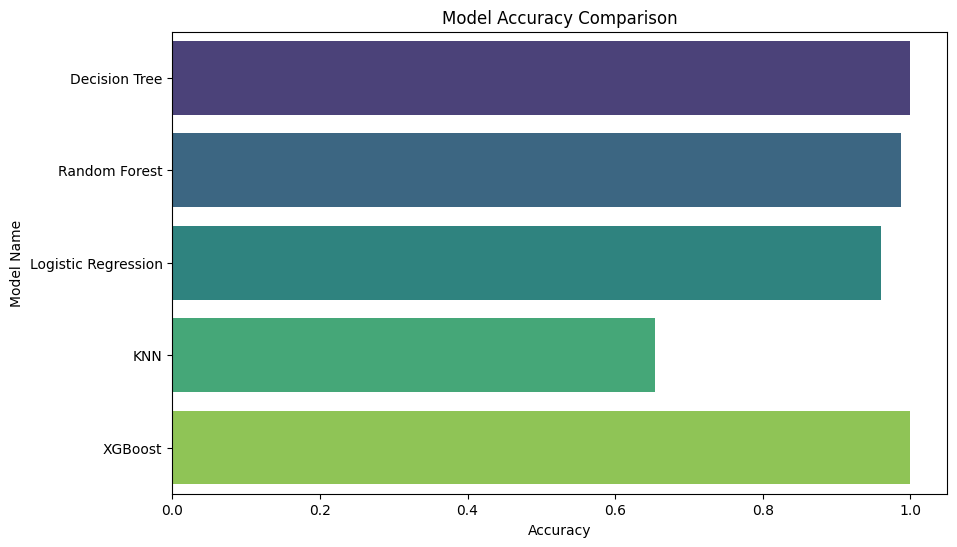

In [17]:
# Create a DataFrame from the results list
results_df = pd.DataFrame(results, columns=[
    "Model Name", "Accuracy", "Precision", "Recall",
    "F1 (Weighted)", "F1 (Macro)", "F1 (Micro)"
])

# Display the table sorted by Accuracy
print("--- Model Performance Comparison ---")
print(results_df.sort_values(by="Accuracy", ascending=False))

# Optional: Plot the accuracy for your report
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model Name", data=results_df, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.show()

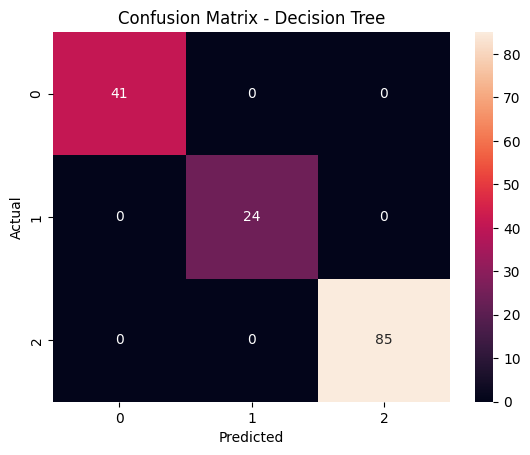

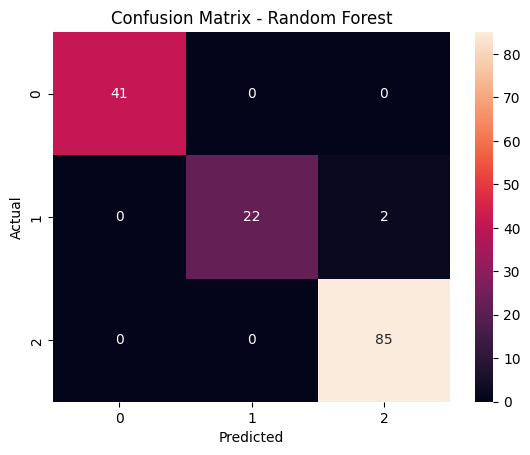

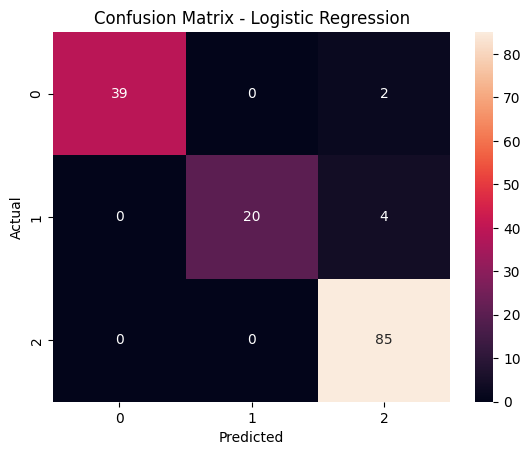

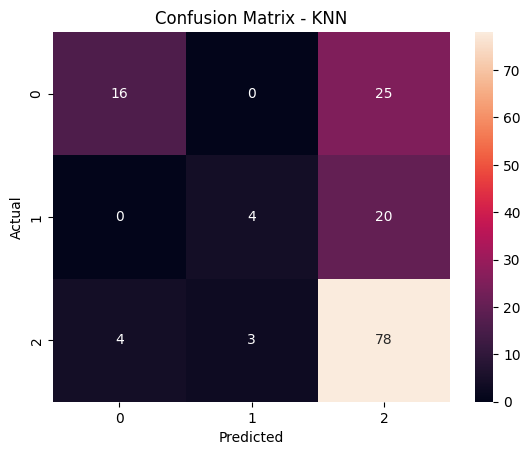

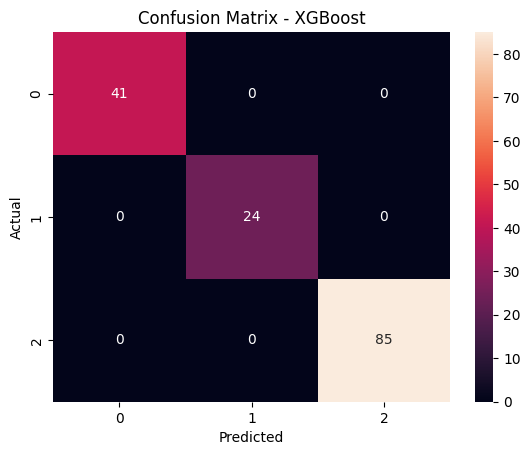

In [19]:
for name, model in models.items():
    # Generate predictions
    y_pred = model.predict(X_test)

    # Create the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plotting the heatmap
    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title("Confusion Matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [20]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n====================================")
    print("Model:", name)
    print("====================================")

    print(classification_report(y_test, y_pred))


Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        85

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      0.92      0.96        24
           2       0.98      1.00      0.99        85

    accuracy                           0.99       150
   macro avg       0.99      0.97      0.98       150
weighted avg       0.99      0.99      0.99       150


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        41
           1       1.00      0.83      0.91        24
   